In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Import Architectural Style
import viz_style
viz_style.set_architectural_style()

# Setup Cache
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

print("Cache initialized.")

Architectural plot style applied (Dark Mode).
Cache initialized.


### Step 1: Session Selection
Filter sessions to find those with recordings in the Primary Visual Cortex (VISp) and other visual areas.

In [7]:
sessions = cache.get_session_table()
print(f"Total Sessions: {len(sessions)}")

# Filter for Brain Observatory 1.1 and VIS areas
VIS_Sessions = sessions[
    (sessions.ecephys_structure_acronyms.apply(lambda x: ('VISam' in x) and ('VISl' in x) and ('VISp' in x) and ('VISal' in x))) 
    & (sessions.session_type.apply(lambda x: 'brain_observatory_1.1' in x))
    & (sessions.probe_count == 6)
]

print(f"Sessions with full VIS coverage: {len(VIS_Sessions)}")
display(VIS_Sessions[['session_type', 'ecephys_structure_acronyms']].head())

Total Sessions: 58
Sessions with full VIS coverage: 12


,session_type,ecephys_structure_acronyms
id,,
719161530,brain_observatory_1.1,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,brain_observatory_1.1,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
750332458,brain_observatory_1.1,"[grey, VISrl, nan, VISal, IntG, IGL, LGd, CA3,..."
750749662,brain_observatory_1.1,"[LP, DG, CA1, VISp, nan, LGd, CA3, VISrl, VPM,..."
754312389,brain_observatory_1.1,"[APN, POL, LP, DG, CA1, VISam, nan, LGd, HPF, ..."


### Step 2: Load Specific Session
We select Session **715093703** for detailed analysis.

In [8]:
session_id = 715093703
session = cache.get_session_data(session_id)
print(f"Session {session_id} loaded.")

print("\n--- Session Metadata ---")
print(session.metadata)

print("\n--- Unit Counts per Structure ---")
print(session.structurewise_unit_counts)

Session 715093703 loaded.

--- Session Metadata ---
{'specimen_name': 'Sst-IRES-Cre;Ai32-386129', 'session_type': 'brain_observatory_1.1', 'full_genotype': 'Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt', 'sex': 'M', 'age_in_days': 118.0, 'rig_equipment_name': 'NP.1', 'num_units': 884, 'num_channels': 2219, 'num_probes': 6, 'num_stimulus_presentations': 70388, 'session_start_time': datetime.datetime(2019, 1, 19, 0, 54, 18, tzinfo=tzoffset(None, -28800)), 'ecephys_session_id': 715093703, 'structure_acronyms': ['PO', 'PoT', 'LP', 'DG', 'CA1', 'VISp', nan, 'LGd', 'CA3', 'VISl', 'VISrl', 'grey', 'VISpm', 'VISam', 'APN', 'MB'], 'stimulus_names': ['spontaneous', 'gabors', 'flashes', 'drifting_gratings', 'natural_movie_three', 'natural_movie_one', 'static_gratings', 'natural_scenes']}

--- Unit Counts per Structure ---
CA1      145
LP       139
grey     117
LGd       82
PO        76
VISrl     76
VISp      60
VISpm     50
VISl      42
VISam     30
APN       26
DG        26
CA3       14
PoT    

### Step 3: Stimulus Inspection
Visualize the visual stimuli presented during the session.

Stimuli presented: ['spontaneous', 'gabors', 'flashes', 'drifting_gratings', 'natural_movie_three', 'natural_movie_one', 'static_gratings', 'natural_scenes']


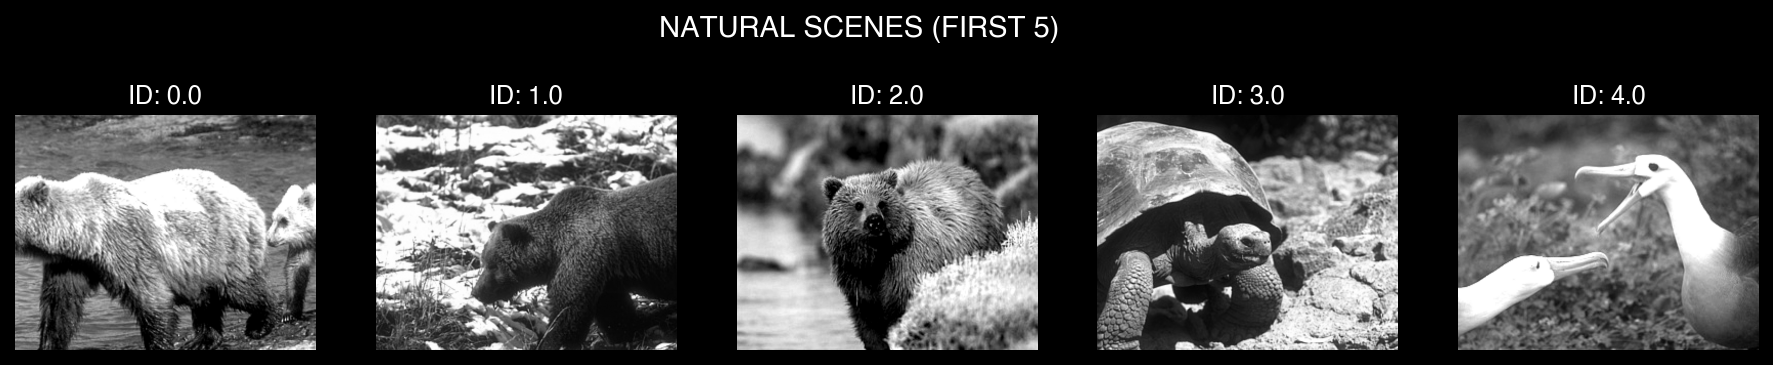


Natural Movie One: 900 frames


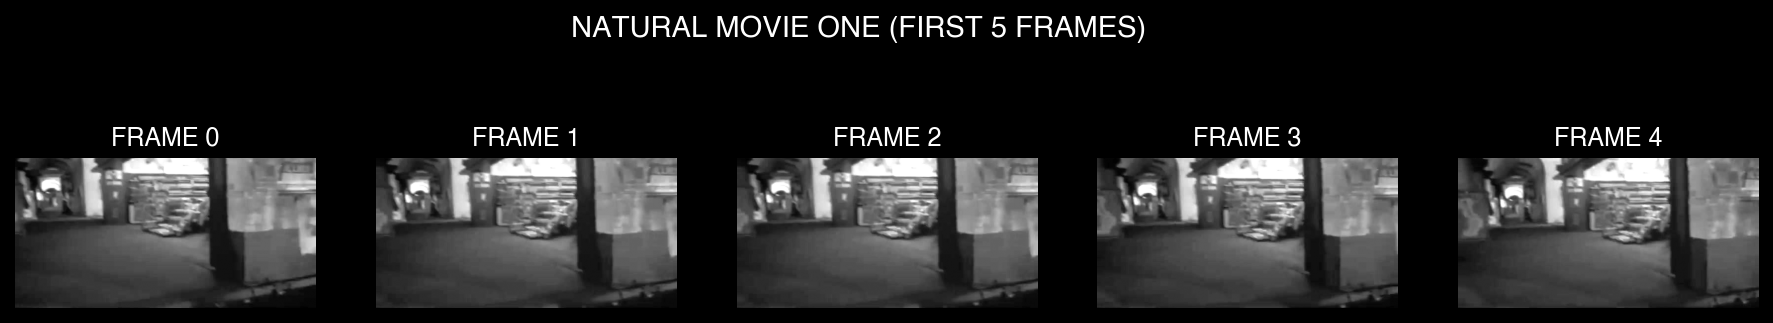

In [9]:
print(f"Stimuli presented: {session.stimulus_names}")

# Visualize Natural Scenes
if 'natural_scenes' in session.stimulus_names:
    table = session.get_stimulus_table('natural_scenes')
    unique_images = np.sort(table['frame'].unique())
    unique_images = unique_images[unique_images != -1]
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle("NATURAL SCENES (FIRST 5)", fontsize=14, color=viz_style.WHITE)
    for i, img_id in enumerate(unique_images[:5]):
        img = cache.get_natural_scene_template(img_id)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"ID: {img_id}", color=viz_style.WHITE)
        axes[i].axis('off')
    plt.show()

# Visualize Natural Movie One
if 'natural_movie_one' in session.stimulus_names:
    movie_template = cache.get_natural_movie_template(1)
    print(f"\nNatural Movie One: {movie_template.shape[0]} frames")
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle("NATURAL MOVIE ONE (FIRST 5 FRAMES)", fontsize=14, color=viz_style.WHITE)
    for i in range(5):
        axes[i].imshow(movie_template[i, :, :], cmap='gray')
        axes[i].set_title(f"FRAME {i}", color=viz_style.WHITE)
        axes[i].axis('off')
    plt.show()

### Step 4: NWB File Structure
Inspect the internal structure of the NWB file using `h5py`.

In [10]:
nwb_path = Path(output_dir) / f"session_{session_id}" / f"session_{session_id}.nwb"
print(f"Inspecting NWB file: {nwb_path}")

if nwb_path.exists():
    with h5py.File(nwb_path, 'r') as f:
        print("\n--- Root Keys ---")
        print(list(f.keys()))
        
        if 'processing' in f:
            print("\n--- Processing Modules ---")
            print(list(f['processing'].keys()))
else:
    print("NWB file not found locally.")

Inspecting NWB file: ../Dataset/RAW/session_715093703/session_715093703.nwb

--- Root Keys ---
['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']

--- Processing Modules ---
['eye_tracking_rig_metadata', 'optotagging', 'running', 'stimulus']
